In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
from pprint import pprint
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

import talib

# from pklib.strategy import *
from pklib.utilities import *
# from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *

# from pklib.rl import *


In [2]:
# from stable_baselines3 import PPO, A2C, DDPG, DQN, SAC
# from stable_baselines3 import TD3
# from stable_baselines3.common.noise import NormalActionNoise
# import pandas as pd
# from stable_baselines3.common.env_checker import check_env
# from stable_baselines3.common.env_util import make_vec_env
# from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
# from sb3_contrib import RecurrentPPO
# from stable_baselines3.common.callbacks import BaseCallback
# from stable_baselines3.common.callbacks import BaseCallback
# from stable_baselines3.common.logger import configure


import gymnasium as gym  # Use Gymnasium instead of gym
from gymnasium.spaces import Discrete, Box

In [3]:
# import ray.rllib.algorithms.dq

In [4]:


def split_dataframes(dataframes, train_size=0.7):
    """
    Split the input dataframes into training and testing sets.

    Parameters:
    dataframes (list): List of pandas DataFrames to split.
    train_size (float): Proportion of the data to use for training (default is 0.7).

    Returns:
    tuple: (train_dfs, test_dfs) Lists of DataFrames for training and testing.
    """
    train_dfs = []
    test_dfs = []

    for df in dataframes:
        # Calculate the split index
        split_index = int(len(df) * train_size)
        
        # Split the DataFrame
        train_df = df.iloc[:split_index]
        test_df = df.iloc[split_index:]
        
        # Append to the respective lists
        train_dfs.append(train_df)
        test_dfs.append(test_df)

    return train_dfs, test_dfs




# Now you can use these split dataframes for training and testing

# df_comp_features = create_comparison_features(df_indicators, compare_columns)
# # percent_diff_thresholds = [-10, -5,-3,-1, 0, 2, 5, 10]
# # df_percent_diffs = create_signed_difference_features_multi(df_indicators,[
# #             ('close', 'tenkan', percent_diff_thresholds),
# #             ('close', 'kijun', percent_diff_thresholds),
# #             ('tenkan', 'kijun', percent_diff_thresholds),
# #             # ('close', 'ema_21', percent_diff_thresholds),
# #             # ('close', 'ema_14', percent_diff_thresholds),
# #             # ('close', 'ema_7', percent_diff_thresholds),
# #             # ('ema_7', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'ema_21', percent_diff_thresholds),
# #             # ('ema_21', 'ema_50', percent_diff_thresholds),
# #             # ('ema_7', 'ema_21', percent_diff_thresholds),
# #         ])


# # df_percent_diffs, _ = remove_highly_correlated_features(df_percent_diffs, threshold=0.7)

# df_features = df_comp_features#.join(df_percent_diffs).dropna()
# # df_features, features_to_drop = remove_highly_correlated_features(df_features, threshold=0.7)
# # print(f'features_to_drop:')
# # pprint(features_to_drop)


In [5]:
def plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df=None, test_trades_df=None):
    """
    Function to plot cumulative PnL for training and testing datasets on two separate axes.
    
    Parameters:
    - train_backtest_df: DataFrame containing the backtest results for the training dataset.
    - train_trades_df: DataFrame containing the trade details for the training dataset.
    - test_backtest_df: DataFrame containing the backtest results for the testing dataset (optional).
    - test_trades_df: DataFrame containing the trade details for the testing dataset (optional).
    """
    
    # Create a single figure with two separate axes (not sharing x-axis)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

    # Plot for the training dataset
    ax1.plot(train_backtest_df['cumulative_pnl'].apply(np.expm1))  # Plot cumulative PnL for training
    ax1.plot(np.append(train_backtest_df.index[:1],train_trades_df.exit_index), np.expm1(np.append(0,train_trades_df['pnl']).cumsum()), alpha=0.3, color='maroon', lw=3)  # Plot trade PnL
    ax1.set_ylabel('Cumulative PnL (Train)')
    ax1.set_title('TRAIN DATASET')  # Add a title for the training plot

    # Plot for the testing dataset (if provided)
    if test_backtest_df is not None:
        ax2.plot(test_backtest_df['cumulative_pnl'].apply(np.expm1))  # Plot cumulative PnL for testing
        ax2.plot(np.append(test_backtest_df.index[:1],test_trades_df.exit_index), np.expm1(np.append(0,test_trades_df['pnl']).cumsum()), alpha=0.3, color='maroon', lw=3)  # Plot trade PnL
        ax2.set_ylabel('Cumulative PnL (Test)')
        ax2.set_title('TEST DATASET')  # Add a title for the testing plot

    # Display the figure
    plt.tight_layout()
    plt.show()

    return fig, ax1, ax2

def perform_backtest(trainer, env):
    """
    Perform backtesting using the provided Ray RLlib-trained model on the test environment.
    
    Parameters:
    - trainer: A trained Ray RLlib agent (e.g., DQNTrainer).
    - env: An instance of TradingEnv, initialized with test data.
    
    Returns:
    - backtest_df: A pandas DataFrame containing the following columns:
        - 'logprice': Log price at each step.
        - 'position': Position held (1 for long, -1 for short, 0 for no position).
        - 'action': Action taken (e.g., 0 = hold, 1 = buy, 2 = sell).
        - 'cumulative_pnl': Cumulative PnL up to each step.
      The DataFrame is indexed by the original `df` index from `env`.
    """
    state, _ = env.reset()
    done = False

    # Initialize lists to store metrics
    positions = []
    actions = []
    cumulative_pnls = []
    indices = []
    trades = []

    # Initialize step counter based on lookback window
    step = env.lookback_window_size

    while not done and step < len(env.df):
        # Use Ray's trained model to compute the next action
        action = trainer.compute_single_action(state)

        # Take a step in the environment
        next_state, reward, done, truncated, info = env.step(action)

        # Log trades if any
        if 'trade_info' in info:
            trades.append(info['trade_info'])

        # Log metrics
        positions.append(info.get('position', 0))
        actions.append(action)
        cumulative_pnls.append(env.cumulative_pnl)

        # Collect the current index from the DataFrame
        current_index = env.df.index[step]
        indices.append(current_index)

        # Move to the next state
        state = next_state
        step += 1

    # Create a DataFrame with the collected metrics
    backtest_df = pd.DataFrame({
        'position': positions,
        'action': actions,
        'cumulative_pnl': cumulative_pnls
    }, index=indices)

    trades_df = pd.DataFrame(trades)

    if not trades_df.empty:
        # Map the entry and exit steps to the corresponding index in the logprice Series
        trades_df['entry_index'] = env.logprice.index[trades_df.entry_step]
        trades_df['exit_index'] = env.logprice.index[trades_df.exit_step]

        # Map the correct log prices based on the entry and exit indices
        trades_df['entry_logprice'] = env.logprice.iloc[trades_df.entry_step.values].values
        trades_df['exit_logprice'] = env.logprice.iloc[trades_df.exit_step.values].values
        trades_df['pnl'] = trades_df['position'] * (trades_df['exit_logprice'] - trades_df['entry_logprice'])

    return backtest_df, trades_df


In [6]:
class TradingEnv(gym.Env):
    def __init__(self, env_config):
        self.df = env_config['df']
        self.logprice = env_config['logprice']
        self.lookback_window_size = env_config['lookback_window_size']
        self.trading_mode = env_config.get('trading_mode', 'both')
        self.verbosity = env_config.get('verbosity', 0)
        
        self.current_step = 0
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.num_positions = 0
        self.position = 0  # 1 = long, 0 = no position, -1 = short

        # Define action space based on trading mode
        if self.trading_mode == 'long_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = long
        elif self.trading_mode == 'short_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = short
        else:  # 'both'
            self.action_space = Discrete(4)  # 0 = hold, 1 = long, 2 = short, 3 = close position
        # self.action_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)
        # Observation space: OHLCV + technical indicators + entry price + position (flattened lookback period + 2 additional features)
        obs_space_shape = (self.lookback_window_size * len(self.df.columns) + 1,)
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        # Ensure enough data for the lookback window
        self.current_step = self.lookback_window_size

        self.entry_logprice = None
        self.cumulative_pnl = 0  # Reset cumulative PnL at the start of each episode
        self.position = 0  # Reset position
        self.num_positions = 0
        self.entry_step = None

        # Get the starting index for the lookback window (ensure it's valid)
        start_index = max(0, self.current_step - self.lookback_window_size)
        initial_observation = self.df.iloc[start_index:self.current_step].values

        # Pad the history if there are fewer observations than the lookback size
        if len(initial_observation) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(initial_observation), len(self.df.columns)))
            initial_observation = np.vstack((padding, initial_observation))

        # Return the initial flattened observation (1D array)
        # The 'info' dictionary is returned for compatibility with Gym environments
        return np.hstack([initial_observation.flatten(),[0]]).astype(np.double), {'cumulative_pnl': self.cumulative_pnl}

    def step(self, action):
        current_logprice = self.logprice.iloc[self.current_step]
        reward = 0
        pnl = 0
        trade_info = {}

        if self.verbosity >= 1:
            print(f"Step: {self.current_step}, Action: {action}, Position: {self.position}, Cumulative PnL: {self.cumulative_pnl}")

        # Handle actions based on trading mode
        if self.trading_mode == 'long_only':
            if action == 1 and self.position == 0:  # Open long position
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")
            elif action == 0 and self.position == 1:  # Close long position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed long position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'short_only':
            if action == 1 and self.position == 0:  # Open short position
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")
            elif action == 0 and self.position == -1:  # Close short position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed short position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'both':
            if action == 1 and self.position != 1:  # Open or switch to long
                if self.position == -1 and self.entry_logprice is not None:  # Close short position first
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from short to long. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")

            elif action == 2 and self.position != -1:  # Open or switch to short
                if self.position == 1 and self.entry_logprice is not None:  # Close long position first
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from long to short. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")

            elif action == 3 and self.position != 0:  # Close position
                if self.entry_logprice is not None:  # Ensure entry price is set
                    pnl = self.position * (current_logprice - self.entry_logprice)
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': self.position,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        # Move to the next step
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1  # End of data
        truncated = False

        # Handle termination case with open position
        if terminated and self.position != 0 and self.entry_logprice is not None:
            pnl = self.position * (current_logprice - self.entry_logprice)
            self.cumulative_pnl += pnl  # Accumulate PnL
            trade_info = {
                'trade_info': {
                    'entry_step': self.entry_step,
                    'exit_step': self.current_step,
                    'position': self.position,
                    'pnl': pnl
                }
            }
            if self.verbosity >= 2:
                print(f"Terminating with open position. Final PnL: {pnl}")
            self.position = 0  # Close position

        
        holding_penalty = 0
        if self.position != 0 and self.entry_step is not None:
            holding_duration = self.current_step - self.entry_step
            max_holding_duration = 50  # Define a threshold for holding too long
            if holding_duration > max_holding_duration:
                holding_penalty = (holding_duration - max_holding_duration) * 0.01  # Example penalty

        # Calculate the reward
        reward = pnl - holding_penalty  # Penalize for holding too long

        # Get the next observation
        obs = self._next_observation()

        # Return observation, reward, termination info, and trade details
        info = {
            'position': self.position,
            'cumulative_pnl': self.cumulative_pnl,
            **trade_info
        }

        return obs, reward, terminated, truncated, info

    def _next_observation(self):
        # Handle edge cases where the current step is less than the lookback window size
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step]

        # If the lookback window is smaller than the full lookback size, pad with earlier rows
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame.values))
        else:
            frame = frame.values

        # Return flattened lookback window and append position and entry price
        return np.hstack([frame.flatten(), [self.position]]).astype(np.double)
    
    def render(self, mode="human"):
        # Print relevant information about the environment (for debugging purposes)
        print(f"Step: {self.current_step}, #Positions: {self.num_positions}, Cumulative PnL: {self.cumulative_pnl:.2f}")



## Naive Deep Q Network, as per Phil Tabor

In [88]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch as T
# from util import plot_learning_curve
import torch as T
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class LinearDeepQNetwork(nn.Module):
    def __init__(self, lr, n_actions, input_dims, hidden_layers):
        """
        :param lr: Learning rate for the optimizer.
        :param n_actions: Number of actions (output dimension).
        :param input_dims: Input dimensions (state space size).
        :param hidden_layers: List of integers where each element represents the number of neurons in a hidden layer.
        """
        super(LinearDeepQNetwork, self).__init__()
        
        # Initialize the first fully connected layer
        self.input_layer = nn.Linear(*input_dims, hidden_layers[0])
        
        # Dynamically create hidden layers based on the hidden_layers list
        self.hidden_layers = nn.ModuleList()
        for i in range(1, len(hidden_layers)):
            self.hidden_layers.append(nn.Linear(hidden_layers[i-1], hidden_layers[i]))
        
        # Output layer
        self.output_layer = nn.Linear(hidden_layers[-1], n_actions)

        # Set up optimizer and loss function
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss = nn.MSELoss()
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
        self.to(self.device)

    def forward(self, state):
        # Pass through input layer
        x = F.relu(self.input_layer(state))
        
        # Pass through hidden layers
        for hidden_layer in self.hidden_layers:
            x = F.relu(hidden_layer(x))
        
        # Output layer
        actions = self.output_layer(x)

        return actions

def plot_learning_curve(x, scores, epsilons, filename):
    fig = plt.figure()
    ax = fig.add_subplot(111, label="1")
    ax2 = fig.add_subplot(111, label="2", frame_on=False)

    ax.plot(x, epsilons, color="C0")
    ax.set_xlabel("Training Steps", color="C0")
    ax.set_ylabel("Epsilon", color="C0")
    ax.tick_params(axis='x', colors="C0")
    ax.tick_params(axis='y', colors="C0")

    N = len(scores)
    running_avg = np.empty(N)
    for t in range(N):
        running_avg[t] = np.mean(scores[max(0, t-100):(t+1)])

    ax2.scatter(x, running_avg, color="C1")
    ax2.axes.get_xaxis().set_visible(False)
    ax2.yaxis.tick_right()
    ax2.set_ylabel('Score', color="C1")
    ax2.yaxis.set_label_position('right')
    ax2.tick_params(axis='y', colors="C1")

    plt.savefig(filename)

# class LinearDeepQNetwork(nn.Module):
#     def __init__(self, lr, n_actions, input_dims):
#         super(LinearDeepQNetwork, self).__init__()

#         self.fc1 = nn.Linear(*input_dims, 128)
#         self.fc2 = nn.Linear(128, n_actions)

#         self.optimizer = optim.Adam(self.parameters(), lr=lr)
#         self.loss = nn.MSELoss()
#         self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
#         self.to(self.device)

#     def forward(self, state):
#         layer1 = F.relu(self.fc1(state))
#         actions = self.fc2(layer1)

#         return actions


class Agent():
    def __init__(self, input_dims, n_actions, lr, gamma=0.99,
                 epsilon=1.0, eps_dec=1e-5, eps_min=0.01, hidden_layers=[128,128]):
        self.lr = lr
        self.input_dims = input_dims
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.eps_dec = eps_dec
        self.eps_min = eps_min
        self.action_space = [i for i in range(self.n_actions)]

        self.Q = LinearDeepQNetwork(self.lr, self.n_actions, self.input_dims, hidden_layers=hidden_layers)

    def compute_single_action(self, observation):
        state = T.tensor(observation, dtype=T.float).to(self.Q.device)
        actions = self.Q.forward(state)
        action = T.argmax(actions).item()
        return action
        
    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state = T.tensor(observation, dtype=T.float).to(self.Q.device)
            actions = self.Q.forward(state)
            action = T.argmax(actions).item()
        else:
            action = np.random.choice(self.action_space)

        return action

    def decrement_epsilon(self):
        self.epsilon = self.epsilon - self.eps_dec \
                        if self.epsilon > self.eps_min else self.eps_min

    def learn(self, state, action, reward, state_):
        self.Q.optimizer.zero_grad()
        states = T.tensor(state, dtype=T.float).to(self.Q.device)
        actions = T.tensor(action).to(self.Q.device)
        rewards = T.tensor(reward, dtype=T.float).to(self.Q.device)
        states_ = T.tensor(state_, dtype=T.float).to(self.Q.device)

        q_pred = self.Q.forward(states)[actions]

        q_next = self.Q.forward(states_).max()

        q_target = rewards + self.gamma*q_next

        loss = self.Q.loss(q_target, q_pred).to(self.Q.device)
        loss.backward()
        self.Q.optimizer.step()
        self.decrement_epsilon()

DF shape: (2085, 35)
Episode: 0
Step: 1458, #Positions: 366, Cumulative PnL: 0.98
Episode: 1
Step: 1458, #Positions: 368, Cumulative PnL: 2.13
Episode: 2
Step: 1458, #Positions: 359, Cumulative PnL: -0.12
Episode: 3
Step: 1458, #Positions: 362, Cumulative PnL: 1.77
Episode: 4
Step: 1458, #Positions: 361, Cumulative PnL: 1.83
Episode: 5
Step: 1458, #Positions: 367, Cumulative PnL: 0.71
Episode: 6
Step: 1458, #Positions: 352, Cumulative PnL: 1.80
Episode: 7
Step: 1458, #Positions: 369, Cumulative PnL: -0.42
Episode: 8
Step: 1458, #Positions: 369, Cumulative PnL: 1.50
Episode: 9
Step: 1458, #Positions: 359, Cumulative PnL: 1.40
Episode: 10
Step: 1458, #Positions: 350, Cumulative PnL: 1.69
Episode: 11
Step: 1458, #Positions: 351, Cumulative PnL: 1.07
Episode: 12
Step: 1458, #Positions: 379, Cumulative PnL: 0.44
Episode: 13
Step: 1458, #Positions: 368, Cumulative PnL: -1.07
Episode: 14
Step: 1458, #Positions: 363, Cumulative PnL: 0.04
Episode: 15
Step: 1458, #Positions: 364, Cumulative PnL:

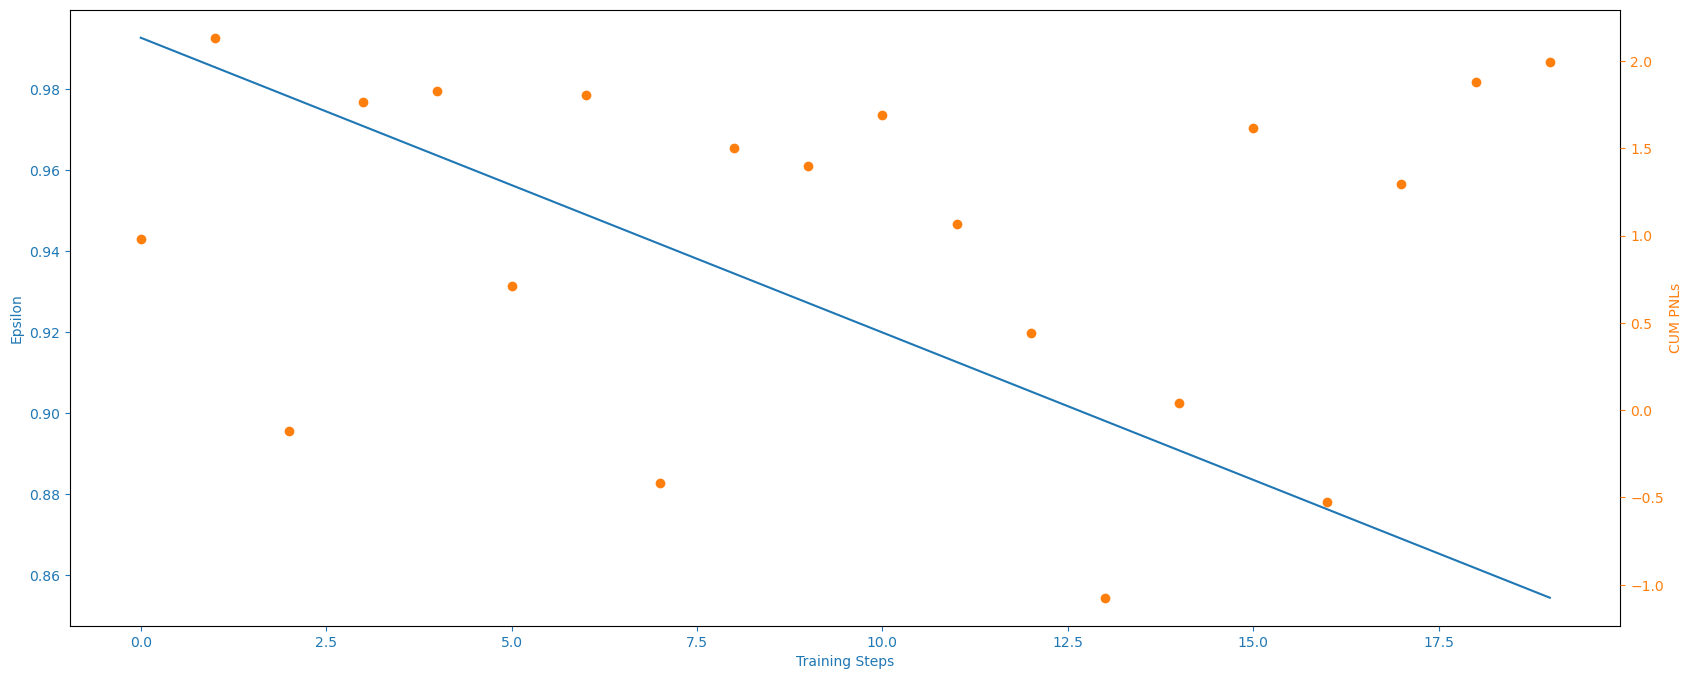

In [115]:

lookback_window_size = 2
trading_mode = 'long_only'# Wrap the environment

params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 24
train_size= 0.7



df = load_candles(exchange, asset, quote, '1h').ffill().bfill()
df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
df.drop('volume', axis=1)
add_ichimoku_cloud_indicator(df, params)

add_shifted_columns(df, periods=[3,7,14,21,50,100], columns=['open','high','low','close'], suffix="_SH")

df = df.dropna()
# df = df['2021':]#.iloc[:10000]
print(f'DF shape: {df.shape}')
df_logprice = df.close.apply(np.log).ffill().bfill()

(train_df_features, train_df_log_prices), (test_df_features, test_df_log_prices) = split_dataframes([df, df_logprice], train_size=train_size)
df

n_train,n_features = train_df_features.shape

train_env_config = {
    'df': train_df_features,  # Your training features DataFrame
    'logprice': train_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}
test_env_config = {
    'df': test_df_features,  # Your training features DataFrame
    'logprice': test_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}

env = train_env = TradingEnv(train_env_config)

n_games = 20
scores = []
eps_history = []
pnls = []
n_positions = []

agent = Agent(lr=0.05, input_dims=env.observation_space.shape,
                n_actions=env.action_space.n, epsilon=1, eps_min=0.01, eps_dec=5e-6, hidden_layers=[128,128])

for i in range(n_games):
    print(f'Episode: {i}')
    score = 0
    done = False
    obs, _ = env.reset()

    while not done:
        action = agent.choose_action(obs)
        obs_, reward, done, truncated, info = env.step(action)
        score += reward
        agent.learn(obs, action, reward, obs_)
        obs = obs_
        
    scores.append(score)
    eps_history.append(agent.epsilon)
    pnls.append(env.cumulative_pnl)
    n_positions.append(env.num_positions)
    env.render()
    # if i % 10 == 0:
    #     avg_score = np.mean(scores[-100:])
    # print('episode ', i, 'score %.1f avg score %.1f epsilon %.2f' %
    #         (score, avg_score, agent.epsilon))
filename = 'trading_naive_dqn.png'
x = list(range(n_games))

fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111, label="1")
ax2 = fig.add_subplot(111, label="2", frame_on=False)

ax.plot(x, eps_history, color="C0")
ax.set_xlabel("Training Steps", color="C0")
ax.set_ylabel("Epsilon", color="C0")
ax.tick_params(axis='x', colors="C0")
ax.tick_params(axis='y', colors="C0")


ax2.scatter(x, pnls, color="C1")
ax2.axes.get_xaxis().set_visible(False)
ax2.yaxis.tick_right()
ax2.set_ylabel('CUM PNLs', color="C1")
ax2.yaxis.set_label_position('right')
ax2.tick_params(axis='y', colors="C1")

# N = len(scores)
# running_avg = np.empty(N)
# for t in range(N):
#     running_avg[t] = np.mean(scores[max(0, t-100):(t+1)])

# ax2.scatter(x, running_avg, color="C1")
# ax2.axes.get_xaxis().set_visible(False)
# ax2.yaxis.tick_right()
# ax2.set_ylabel('Score', color="C1")
# ax2.yaxis.set_label_position('right')
# ax2.tick_params(axis='y', colors="C1")


## RL with Deep Convolutional Netork

In [38]:
import os
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

class DeepQNetwork(nn.Module):
    def __init__(self, lr, n_actions, name, input_dims, chkpt_dir):
        super(DeepQNetwork, self).__init__()
        self.checkpoint_dir = chkpt_dir
        self.checkpoint_file = os.path.join(self.checkpoint_dir, name)

        self.conv1 = nn.Conv2d(input_dims[0], 32, 8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, 4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, 3, stride=1)

        fc_input_dims = self.calculate_conv_output_dims(input_dims)

        self.fc1 = nn.Linear(fc_input_dims, 512)
        self.fc2 = nn.Linear(512, n_actions)

        self.optimizer = optim.RMSprop(self.parameters(), lr=lr)

        self.loss = nn.MSELoss()
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
        self.to(self.device)

    def calculate_conv_output_dims(self, input_dims):
        state = T.zeros(1, *input_dims)
        dims = self.conv1(state)
        dims = self.conv2(dims)
        dims = self.conv3(dims)
        return int(np.prod(dims.size()))

    def forward(self, state):
        conv1 = F.relu(self.conv1(state))
        conv2 = F.relu(self.conv2(conv1))
        conv3 = F.relu(self.conv3(conv2))
        # conv3 shape is BS x n_filters x H x W
        conv_state = conv3.view(conv3.size()[0], -1)
        # conv_state shape is BS x (n_filters * H * W)
        flat1 = F.relu(self.fc1(conv_state))
        actions = self.fc2(flat1)

        return actions

    def save_checkpoint(self):
        print('... saving checkpoint ...')
        T.save(self.state_dict(), self.checkpoint_file)

    def load_checkpoint(self):
        print('... loading checkpoint ...')
        self.load_state_dict(T.load(self.checkpoint_file))

In [8]:
import numpy as np

class ReplayBuffer(object):
    def __init__(self, max_size, input_shape, n_actions):
        self.mem_size = max_size
        self.mem_cntr = 0
        self.state_memory = np.zeros((self.mem_size, *input_shape),
                                     dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *input_shape),
                                         dtype=np.float32)

        self.action_memory = np.zeros(self.mem_size, dtype=np.int64)
        self.reward_memory = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory = np.zeros(self.mem_size, dtype=np.bool)

    def store_transition(self, state, action, reward, state_, done):
        index = self.mem_cntr % self.mem_size
        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.action_memory[index] = action
        self.reward_memory[index] = reward
        self.terminal_memory[index] = done
        self.mem_cntr += 1

    def sample_buffer(self, batch_size):
        max_mem = min(self.mem_cntr, self.mem_size)
        batch = np.random.choice(max_mem, batch_size, replace=False)

        states = self.state_memory[batch]
        actions = self.action_memory[batch]
        rewards = self.reward_memory[batch]
        states_ = self.new_state_memory[batch]
        terminal = self.terminal_memory[batch]

        return states, actions, rewards, states_, terminal

In [61]:
import collections
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

def plot_learning_curve(x, scores, epsilons, filename, lines=None):
    fig=plt.figure()
    ax=fig.add_subplot(111, label="1")
    ax2=fig.add_subplot(111, label="2", frame_on=False)

    ax.plot(x, epsilons, color="C0")
    ax.set_xlabel("Training Steps", color="C0")
    ax.set_ylabel("Epsilon", color="C0")
    ax.tick_params(axis='x', colors="C0")
    ax.tick_params(axis='y', colors="C0")

    N = len(scores)
    running_avg = np.empty(N)
    for t in range(N):
	    running_avg[t] = np.mean(scores[max(0, t-20):(t+1)])

    ax2.scatter(x, running_avg, color="C1")
    ax2.axes.get_xaxis().set_visible(False)
    ax2.yaxis.tick_right()
    ax2.set_ylabel('Score', color="C1")
    ax2.yaxis.set_label_position('right')
    ax2.tick_params(axis='y', colors="C1")

    if lines is not None:
        for line in lines:
            plt.axvline(x=line)

    plt.savefig(filename)

class RepeatActionAndMaxFrame(gym.Wrapper):
    def __init__(self, env=None, repeat=4, clip_reward=False, no_ops=0,
                 fire_first=False):
        super(RepeatActionAndMaxFrame, self).__init__(env)
        self.repeat = repeat
        self.shape = env.observation_space.low.shape
        self.frame_buffer = np.zeros_like((2, self.shape))
        self.clip_reward = clip_reward
        self.no_ops = no_ops
        self.fire_first = fire_first

    def step(self, action):
        t_reward = 0.0
        done = False
        for i in range(self.repeat):
            obs, reward, done, info = self.env.step(action)
            if self.clip_reward:
                reward = np.clip(np.array([reward]), -1, 1)[0]
            t_reward += reward
            idx = i % 2
            self.frame_buffer[idx] = obs
            if done:
                break

        max_frame = np.maximum(self.frame_buffer[0], self.frame_buffer[1])
        return max_frame, t_reward, done, info

    def reset(self, seed, options):
        obs = self.env.reset(seed=seed, options=options)
        no_ops = np.random.randint(self.no_ops)+1 if self.no_ops > 0 else 0
        for _ in range(no_ops):
            _, _, done, _ = self.env.step(0)
            if done:
                self.env.reset()
        if self.fire_first:
            assert self.env.unwrapped.get_action_meanings()[1] == 'FIRE'
            obs, _, _, _ = self.env.step(1)

        self.frame_buffer = np.zeros_like((2,self.shape))
        self.frame_buffer[0] = obs

        return obs

class PreprocessFrame(gym.ObservationWrapper):
    def __init__(self, shape, env=None):
        super(PreprocessFrame, self).__init__(env)
        self.shape = (shape[2], shape[0], shape[1])
        self.observation_space = gym.spaces.Box(low=0.0, high=1.0,
                                    shape=self.shape, dtype=np.float32)

    def observation(self, obs):
        new_frame = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        resized_screen = cv2.resize(new_frame, self.shape[1:],
                                    interpolation=cv2.INTER_AREA)
        new_obs = np.array(resized_screen, dtype=np.uint8).reshape(self.shape)
        new_obs = new_obs / 255.0

        return new_obs

class StackFrames(gym.ObservationWrapper):
    def __init__(self, env, repeat):
        super(StackFrames, self).__init__(env)
        self.observation_space = gym.spaces.Box(
                            env.observation_space.low.repeat(repeat, axis=0),
                            env.observation_space.high.repeat(repeat, axis=0),
                            dtype=np.float32)
        self.stack = collections.deque(maxlen=repeat)

    def reset(self, seed=None, options=None):
        self.stack.clear()
        observation = self.env.reset(seed=seed,options=options)
        for _ in range(self.stack.maxlen):
            self.stack.append(observation)

        return np.array(self.stack).reshape(self.observation_space.low.shape)

    def observation(self, observation):
        self.stack.append(observation)

        return np.array(self.stack).reshape(self.observation_space.low.shape)

def make_env(env_name, env_config, shape=(84,84,1), repeat=4, clip_rewards=False,
             no_ops=0, fire_first=False):
    env = gym.make(env_name,env_config=env_config)
    env = RepeatActionAndMaxFrame(env, repeat, clip_rewards, no_ops, fire_first)
    env = PreprocessFrame(shape, env)
    env = StackFrames(env, repeat)

    return env

In [57]:
import numpy as np
import torch as T
# from deep_q_network import DeepQNetwork
# from replay_memory import ReplayBuffer

class DQNAgent(object):
    def __init__(self, gamma, epsilon, lr, n_actions, input_dims,
                 mem_size, batch_size, eps_min=0.01, eps_dec=5e-7,
                 replace=1000, algo=None, env_name=None, chkpt_dir='tmp/dqn',env_config=None):
        self.gamma = gamma
        self.epsilon = epsilon
        self.lr = lr
        self.n_actions = n_actions
        self.input_dims = input_dims
        self.batch_size = batch_size
        self.eps_min = eps_min
        self.eps_dec = eps_dec
        self.replace_target_cnt = replace
        self.algo = algo
        self.env_name = env_name
        self.chkpt_dir = chkpt_dir
        self.action_space = [i for i in range(n_actions)]
        self.learn_step_counter = 0

        self.memory = ReplayBuffer(mem_size, input_dims, n_actions)

        self.q_eval = DeepQNetwork(self.lr, self.n_actions,
                                    input_dims=self.input_dims,
                                    name=self.env_name+'_'+self.algo+'_q_eval',
                                    chkpt_dir=self.chkpt_dir)

        self.q_next = DeepQNetwork(self.lr, self.n_actions,
                                    input_dims=self.input_dims,
                                    name=self.env_name+'_'+self.algo+'_q_next',
                                    chkpt_dir=self.chkpt_dir)

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state = T.tensor([observation],dtype=T.float).to(self.q_eval.device)
            actions = self.q_eval.forward(state)
            action = T.argmax(actions).item()
        else:
            action = np.random.choice(self.action_space)

        return action

    def store_transition(self, state, action, reward, state_, done):
        self.memory.store_transition(state, action, reward, state_, done)

    def sample_memory(self):
        state, action, reward, new_state, done = \
                                self.memory.sample_buffer(self.batch_size)

        states = T.tensor(state).to(self.q_eval.device)
        rewards = T.tensor(reward).to(self.q_eval.device)
        dones = T.tensor(done).to(self.q_eval.device)
        actions = T.tensor(action).to(self.q_eval.device)
        states_ = T.tensor(new_state).to(self.q_eval.device)

        return states, actions, rewards, states_, dones

    def replace_target_network(self):
        if self.learn_step_counter % self.replace_target_cnt == 0:
            self.q_next.load_state_dict(self.q_eval.state_dict())

    def decrement_epsilon(self):
        self.epsilon = self.epsilon - self.eps_dec \
                           if self.epsilon > self.eps_min else self.eps_min

    def save_models(self):
        self.q_eval.save_checkpoint()
        self.q_next.save_checkpoint()

    def load_models(self):
        self.q_eval.load_checkpoint()
        self.q_next.load_checkpoint()

    def learn(self):
        if self.memory.mem_cntr < self.batch_size:
            return

        self.q_eval.optimizer.zero_grad()

        self.replace_target_network()

        states, actions, rewards, states_, dones = self.sample_memory()
        indices = np.arange(self.batch_size)

        q_pred = self.q_eval.forward(states)[indices, actions]
        q_next = self.q_next.forward(states_).max(dim=1)[0]

        q_next[dones] = 0.0
        q_target = rewards + self.gamma*q_next

        loss = self.q_eval.loss(q_target, q_pred).to(self.q_eval.device)
        loss.backward()
        self.q_eval.optimizer.step()
        self.learn_step_counter += 1

        self.decrement_epsilon()

In [63]:
class TradingEnv(gym.Env):
    def __init__(self, env_config=None):
        self.df = env_config['df']
        self.logprice = env_config['logprice']
        self.lookback_window_size = env_config['lookback_window_size']
        self.trading_mode = env_config.get('trading_mode', 'both')
        self.verbosity = env_config.get('verbosity', 0)
        
        self.current_step = 0
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.num_positions = 0
        self.position = 0  # 1 = long, 0 = no position, -1 = short

        # Define action space based on trading mode
        if self.trading_mode == 'long_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = long
        elif self.trading_mode == 'short_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = short
        else:  # 'both'
            self.action_space = Discrete(4)  # 0 = hold, 1 = long, 2 = short, 3 = close position
        # self.action_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)
        # Observation space: OHLCV + technical indicators + entry price + position (flattened lookback period + 2 additional features)
        # obs_space_shape = (self.lookback_window_size * len(self.df.columns) + 1,)
        obs_space_shape = (len(self.df.columns) + 1, self.lookback_window_size )
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        # Ensure enough data for the lookback window
        self.current_step = self.lookback_window_size

        self.entry_logprice = None
        self.cumulative_pnl = 0  # Reset cumulative PnL at the start of each episode
        self.position = 0  # Reset position
        self.num_positions = 0
        self.entry_step = None

        # Get the starting index for the lookback window (ensure it's valid)
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step].values

        # Pad the history if there are fewer observations than the lookback size
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame))

        frame = np.hstack((frame, np.full((frame.shape[0],1), self.position))).astype(np.float32)
        # Return the initial flattened observation (1D array)
        # The 'info' dictionary is returned for compatibility with Gym environments
        # return np.hstack([initial_observation.flatten(),[0]]).astype(np.double), {'cumulative_pnl': self.cumulative_pnl}
        return frame, {'cumulative_pnl': self.cumulative_pnl}

    def step(self, action):
        current_logprice = self.logprice.iloc[self.current_step]
        reward = 0
        pnl = 0
        trade_info = {}

        if self.verbosity >= 1:
            print(f"Step: {self.current_step}, Action: {action}, Position: {self.position}, Cumulative PnL: {self.cumulative_pnl}")

        # Handle actions based on trading mode
        if self.trading_mode == 'long_only':
            if action == 1 and self.position == 0:  # Open long position
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")
            elif action == 0 and self.position == 1:  # Close long position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed long position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'short_only':
            if action == 1 and self.position == 0:  # Open short position
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")
            elif action == 0 and self.position == -1:  # Close short position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed short position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'both':
            if action == 1 and self.position != 1:  # Open or switch to long
                if self.position == -1 and self.entry_logprice is not None:  # Close short position first
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from short to long. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")

            elif action == 2 and self.position != -1:  # Open or switch to short
                if self.position == 1 and self.entry_logprice is not None:  # Close long position first
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from long to short. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")

            elif action == 3 and self.position != 0:  # Close position
                if self.entry_logprice is not None:  # Ensure entry price is set
                    pnl = self.position * (current_logprice - self.entry_logprice)
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': self.position,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        # Move to the next step
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1  # End of data
        truncated = False

        # Handle termination case with open position
        if terminated and self.position != 0 and self.entry_logprice is not None:
            pnl = self.position * (current_logprice - self.entry_logprice)
            self.cumulative_pnl += pnl  # Accumulate PnL
            trade_info = {
                'trade_info': {
                    'entry_step': self.entry_step,
                    'exit_step': self.current_step,
                    'position': self.position,
                    'pnl': pnl
                }
            }
            if self.verbosity >= 2:
                print(f"Terminating with open position. Final PnL: {pnl}")
            self.position = 0  # Close position

        
        holding_penalty = 0
        if self.position != 0 and self.entry_step is not None:
            holding_duration = self.current_step - self.entry_step
            max_holding_duration = 50  # Define a threshold for holding too long
            if holding_duration > max_holding_duration:
                holding_penalty = (holding_duration - max_holding_duration) * 0.01  # Example penalty

        # Calculate the reward
        reward = pnl - holding_penalty  # Penalize for holding too long

        # Get the next observation
        obs = self._next_observation()

        # Return observation, reward, termination info, and trade details
        info = {
            'position': self.position,
            'cumulative_pnl': self.cumulative_pnl,
            **trade_info
        }

        return obs, reward, terminated, truncated, info

    def _next_observation(self):
        # Handle edge cases where the current step is less than the lookback window size
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step]

        # If the lookback window is smaller than the full lookback size, pad with earlier rows
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame.values))
        else:
            frame = frame.values

        frame = np.hstack((frame, np.full((frame.shape[0],1), self.position))).astype(np.float32)
        return frame
        # Return flattened lookback window and append position and entry price
        # return np.hstack([frame.flatten(), [self.position]]).astype(np.double)
    
    def render(self, mode="human"):
        # Print relevant information about the environment (for debugging purposes)
        print(f"Step: {self.current_step}, #Positions: {self.num_positions}, Cumulative PnL: {self.cumulative_pnl:.2f}")


def make_env(env_name, env_config, shape=(84,84,1), repeat=4, clip_rewards=False,
             no_ops=0, fire_first=False):
    env = gym.make(env_name,env_config=env_config)
    # env = RepeatActionAndMaxFrame(env, repeat, clip_rewards, no_ops, fire_first)
    # env = PreprocessFrame(shape, env)
    # env = StackFrames(env, repeat)

    return env

In [59]:

lookback_window_size = 5
trading_mode = 'long_only'# Wrap the environment

params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 24
train_size= 0.7



df = load_candles(exchange, asset, quote, '1h').ffill().bfill()
df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
df.drop('volume', axis=1)
add_ichimoku_cloud_indicator(df, params)

add_shifted_columns(df, periods=[3,7,14,21,50,100], columns=['open','high','low','close'], suffix="_SH")

df = df.dropna()
# df = df['2021':]#.iloc[:10000]
print(f'DF shape: {df.shape}')
df_logprice = df.close.apply(np.log).ffill().bfill()

(train_df_features, train_df_log_prices), (test_df_features, test_df_log_prices) = split_dataframes([df, df_logprice], train_size=train_size)
df

n_train,n_features = train_df_features.shape


DF shape: (2085, 35)


In [64]:
from gymnasium.envs.registration import register

register(
    id='TradingEnv-v0',   # Unique id for the environment
    entry_point=TradingEnv,
    # entry_point='__main__:TradingEnv',  # Path to the custom environment
    # max_episode_steps=200,  # Optional: max number of steps per episode
)

# Step 3: Create the environment using gymnasium.make
# env = gym.make('TradingEnv-v0')

train_env_config = {
    'df': train_df_features,  # Your training features DataFrame
    'logprice': train_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}
test_env_config = {
    'df': test_df_features,  # Your training features DataFrame
    'logprice': test_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}

# env = train_env = TradingEnv(train_env_config)

env = make_env('TradingEnv-v0',env_config=train_env_config)
#env = gym.make('CartPole-v1')
best_score = -np.inf
load_checkpoint = False
n_games = 250
# agent = Agent(lr=0.05, input_dims=env.observation_space.shape,
#                 n_actions=env.action_space.n, epsilon=1, eps_min=0.01, eps_dec=5e-6, hidden_layers=[128,128])
agent = DQNAgent(gamma=0.99, epsilon=1, lr=0.0001,
                     input_dims=(env.observation_space.shape),
                     n_actions=env.action_space.n, mem_size=50000, eps_min=0.1,
                     batch_size=32, replace=1000, eps_dec=1e-5,
                     chkpt_dir='models/', algo='DQNAgent',
                     env_name='TradingEnv-v0', env_config=train_env_config)


n_games = 20
scores = []
eps_history = []
pnls = []
n_positions = []

for i in range(n_games):
    print(f'Episode: {i}')
    score = 0
    done = False
    obs, _ = env.reset()

    while not done:
        action = agent.choose_action(obs)
        obs_, reward, done, truncated, info = env.step(action)
        score += reward
        agent.learn(obs, action, reward, obs_)
        obs = obs_
        
    scores.append(score)
    eps_history.append(agent.epsilon)
    pnls.append(env.cumulative_pnl)
    n_positions.append(env.num_positions)
    env.render()
    # if i % 10 == 0:
    #     avg_score = np.mean(scores[-100:])
    # print('episode ', i, 'score %.1f avg score %.1f epsilon %.2f' %
    #         (score, avg_score, agent.epsilon))
filename = 'trading_naive_dqn.png'
x = list(range(n_games))

fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111, label="1")
ax2 = fig.add_subplot(111, label="2", frame_on=False)

ax.plot(x, eps_history, color="C0")
ax.set_xlabel("Training Steps", color="C0")
ax.set_ylabel("Epsilon", color="C0")
ax.tick_params(axis='x', colors="C0")
ax.tick_params(axis='y', colors="C0")


ax2.scatter(x, pnls, color="C1")
ax2.axes.get_xaxis().set_visible(False)
ax2.yaxis.tick_right()
ax2.set_ylabel('CUM PNLs', color="C1")
ax2.yaxis.set_label_position('right')
ax2.tick_params(axis='y', colors="C1")

# N = len(scores)
# running_avg = np.empty(N)
# for t in range(N):
#     running_avg[t] = np.mean(scores[max(0, t-100):(t+1)])

# ax2.scatter(x, running_avg, color="C1")
# ax2.axes.get_xaxis().set_visible(False)
# ax2.yaxis.tick_right()
# ax2.set_ylabel('Score', color="C1")
# ax2.yaxis.set_label_position('right')
# ax2.tick_params(axis='y', colors="C1")


RuntimeError: Given groups=1, weight of size [32, 36, 8, 8], expected input[1, 1, 36, 5] to have 36 channels, but got 1 channels instead

## More cool stuff

In [ ]:
train_trades_df

AttributeError: 'DataFrame' object has no attribute 'exit_index'

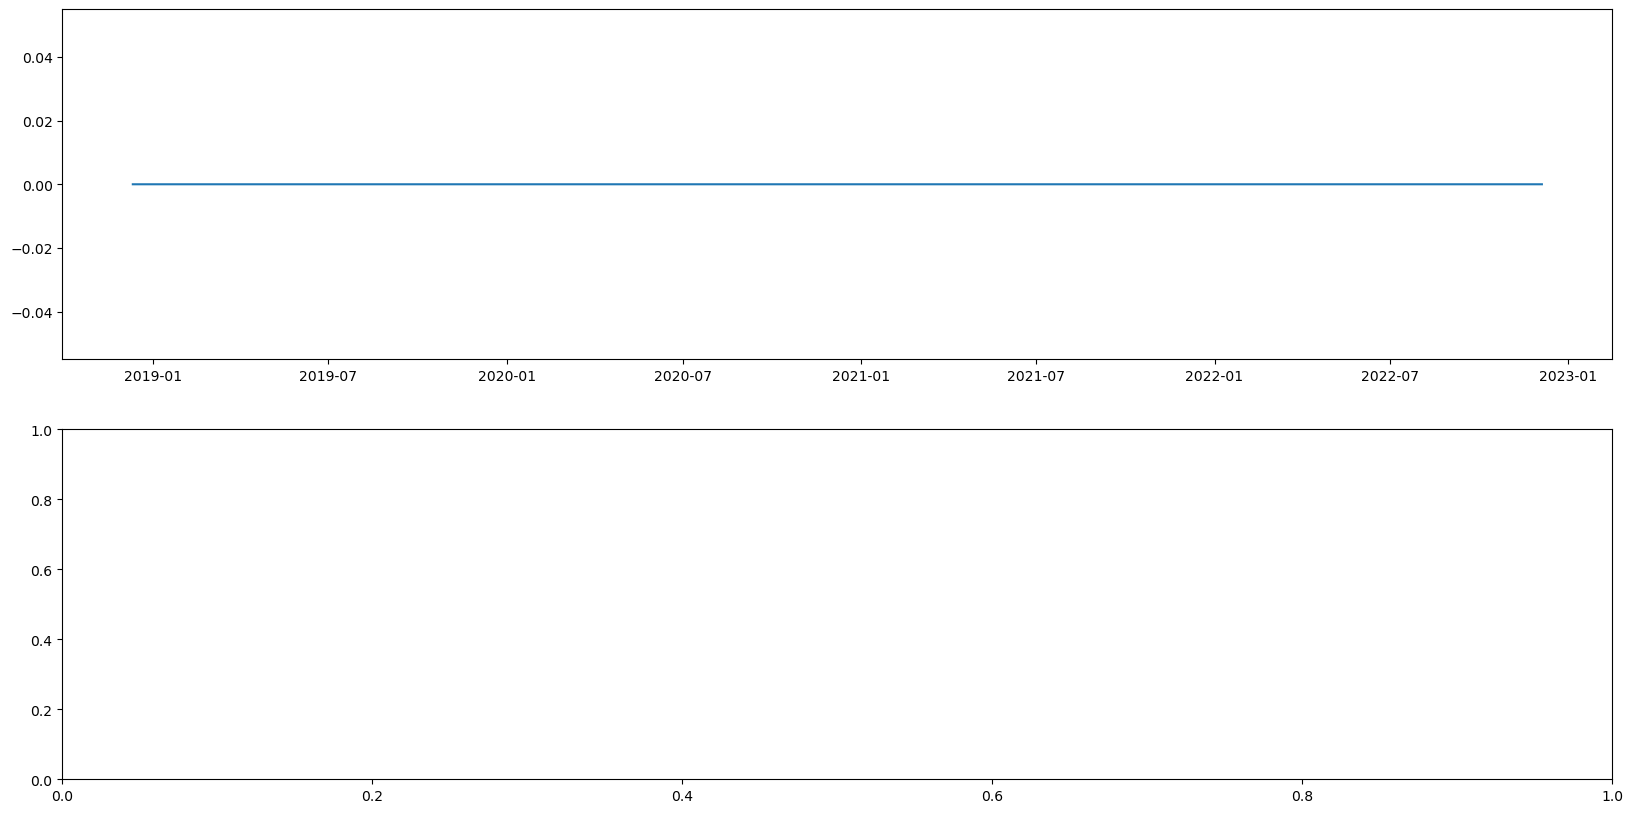

In [113]:

train_env = TradingEnv(train_env_config)
train_backtest_df,train_trades_df = perform_backtest(agent, train_env)

test_backtest_df,test_trades_df = None, None
if(len(test_df_features) > 0):
    test_env = TradingEnv(test_env_config)
    test_backtest_df,test_trades_df = perform_backtest(agent, test_env)

    # Create a single figure with two separate axes (not sharing x-axis)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

    # Plot for the training dataset
    ax1.plot(train_backtest_df['cumulative_pnl'].apply(np.expm1))  # Plot cumulative PnL for training
    ax1.plot(np.append(train_backtest_df.index[:1],train_trades_df.exit_index), np.expm1(np.append(0,train_trades_df['pnl']).cumsum()), alpha=0.3, color='maroon', lw=3)  # Plot trade PnL
    ax1.set_ylabel('Cumulative PnL (Train)')
    ax1.set_title('TRAIN DATASET')  # Add a title for the training plot

    # Plot for the testing dataset (if provided)
    if test_backtest_df is not None:
        ax2.plot(test_backtest_df['cumulative_pnl'].apply(np.expm1))  # Plot cumulative PnL for testing
        ax2.plot(np.append(test_backtest_df.index[:1],test_trades_df.exit_index), np.expm1(np.append(0,test_trades_df['pnl']).cumsum()), alpha=0.3, color='maroon', lw=3)  # Plot trade PnL
        ax2.set_ylabel('Cumulative PnL (Test)')
        ax2.set_title('TEST DATASET')  # Add a title for the testing plot

    # Display the figure
    plt.tight_layout()
    plt.show()

## DQN

In [ ]:
# params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
# # Parameters
# exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 8

# (train_df, train_indicators, train_features, train_log_prices), \
#     (test_df, test_indicators, test_features, test_log_prices) = prepare_dfs(exchange, asset, quote, nhours, lookback_window_size, train_size=0.7, params=params)
# lookback_window_size = int(24/nhours) * 2

lookback_window_size = 1
trading_mode = 'long_only'# Wrap the environment

params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 8
train_size= 1



df = load_candles(exchange, asset, quote, '1h').ffill().bfill()
df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
df.drop('volume', axis=1)
# add_bollinger_bands(df, periods=[9,14,21], multiplier=2)
# add_rsi_columns(df,periods=[9,14,21])
# add_adx_columns(df,periods=[9,14,21])
# add_mom_columns(df,periods=[3,5,7,9,14,21,50,100])
# add_ema_columns(df,periods=[3,5,7,9,7,14,21,50,100])
# add_sma_columns(df,periods=[3,5,7,9,7,14,21,50,100])
# add_std_columns(df,periods=[3,5,7,9,7,14,21])
# log_price_over_ma_columns(df,periods=[3,5,9,14,21,50])
# add_sma_columns(df,periods=[14,21,50,100,200])
# add_std_columns(df,periods=[14,21,50,100,200])
# add_donchian_columns(df,periods=[9,14,21,50])
# add_rolling_max_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
# add_rolling_min_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
# add_rolling_max_columns(df,periods=[5,9,14,21], column="high")
add_rolling_min_columns(df,periods=[5,9,14,21], column="low")

### Informative df
nhours_informative = 24
df_informative = df[["open","high","low","close","volume"]].resample(f'{nhours_informative}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
# log_price_over_ma_columns(df_informative,periods=[9,14,21,50])
# add_bollinger_bands(df_informative, periods=[9,14,21,50], multiplier=2)
# add_rolling_max_columns(df_informative,periods=[5,7,14,21,50], column="close")
add_rolling_min_columns(df_informative,periods=[3,5,7,14,21,50], column="close")
df = pd.merge(df, df_informative, left_index=True, right_index=True, how='left', suffixes=("","_info1")).ffill()

### Informative df
# nhours_informative = 24*3
# df_informative = df[["open","high","low","close","volume"]].resample(f'{nhours_informative}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
# # log_price_over_ma_columns(df_informative,periods=[9,14,21,50])
# # add_bollinger_bands(df_informative, periods=[9,14,21,50], multiplier=2)
# # add_rolling_max_columns(df_informative,periods=[5,7,14,21,50], column="close")
# add_rolling_min_columns(df_informative,periods=[3,5,7,14,21,50], column="close")
# df = pd.merge(df, df_informative, left_index=True, right_index=True, how='left', suffixes=("","_info2")).ffill()

# ### Informative df
# nhours_informative = 24*7
# df_informative = df[["open","high","low","close","volume"]].resample(f'{nhours_informative}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
# # log_price_over_ma_columns(df_informative,periods=[9,14,21,50])
# # add_bollinger_bands(df_informative, periods=[9,14,21,50], multiplier=2)
# # add_rolling_max_columns(df_informative,periods=[5,7,14,21,50], column="close")
# add_rolling_min_columns(df_informative,periods=[3,5,7,14,21,50], column="close")
# df = pd.merge(df, df_informative, left_index=True, right_index=True, how='left', suffixes=("","_info3")).ffill()


add_shifted_columns(df, periods=[3,7,14,21], columns=['open','high','low','close'], suffix="_SH")
df = df.dropna()
df = df['2021':]#.iloc[:10000]
print(f'DF shape: {df.shape}')
df_logprice = df.close.apply(np.log).ffill().bfill()

(train_df_features, train_df_log_prices), (test_df_features, test_df_log_prices) = split_dataframes([df, df_logprice], train_size=train_size)
df

n_train,n_features = train_df_features.shape


def env_creator(env_config):
    return TradingEnv(env_config=env_config)

register_env("TradingEnv-v0", env_creator)

# Define model architecture for RLlib
# model_config = {
#     "fcnet_hiddens": [64, 64],  # Architecture: 3 layers
#     "fcnet_activation": "relu",
# }
train_env_config = {
    'df': train_df_features,  # Your training features DataFrame
    'logprice': train_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 1
}
test_env_config = {
    'df': train_df_features,  # Your training features DataFrame
    'logprice': train_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 1
}
# DQN training config
config = {
    "env": "TradingEnv-v0",  # Use the registered environment
    "env_config": train_env_config,  # Pass the environment configuration
    "callbacks": CustomPnLCallback,  # Use custom callback to track PnL and rewards
    "framework": "torch",  # or "torch", depending on your preference
    "num_workers": 1,  # Use only one worker to avoid parallel environment sampling
    "num_envs_per_worker": 1,  # Ensure a single environment per worker
    "rollout_fragment_length": n_features,  # Use the entire dataset in one go
    "train_batch_size": n_features,  # Match the batch size to the dataset size
    "timesteps_per_iteration": n_features,  # Don't limit the number of timesteps per iteration
    "gamma": 0.995,  # Discount factor
    "exploration_config": {
        "epsilon_timesteps": 10000,  # Timesteps over which to anneal epsilon
        "final_epsilon": 0.01,  # Final exploration epsilon
    },
    "model": {
        "fcnet_hiddens": [256, 256],  # Neural network architecture
        "fcnet_activation": "relu",  # Activation function
    },
}

config.update({
    "n_step": 1,  # multi-step DQN
    "dueling": True,  # use dueling architecture
    "double_q": True,  # use double DQN
    # "prioritized_replay": True,  # use prioritized replay buffer
})


# ray.init(ignore_reinit_error=True)

# You can use DQN or PPO trainers in RLlib
trainer = dqn.DQN(config=config)  # or ppo.PPOTrainer(config=config)

# Train the model using RLlib's DQNTrainer (or PPOTrainer)
num_iterations = 10  # You can change this based on your needs   
for i in range(num_iterations):
    result = trainer.train()
    print(f"Training iteration: {i+1}")
    # print(f"Mean reward: {result['episode_reward_mean']}")
    print(f"Total timesteps: {result['timesteps_total']}")
    print("----")
    # pprint(result)

# Save the trained model
checkpoint = trainer.save()
print(f"Checkpoint saved at {checkpoint}")

# Save the trained model
# model.save("dqn_model")
# with open('dqn_env.pkl', 'wb') as f: pickle.dump(train_env, f)
# tensorboard --logdir tensorboard_logs/


# Shutdown Ray
# ray.shutdown()

In [ ]:

# model.learn(total_timesteps=100000, callback=[episode_logging_callback])
# model.save("dqn_custom_policy")
test_env_config = {
    'df': test_features,  # Your training features DataFrame
    'logprice': test_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}
train_env = TradingEnv(train_env_config)
train_backtest_df,train_trades_df = perform_backtest(trainer, train_env)

test_backtest_df,test_trades_df = None, None
if(len(test_df) > 0):
    test_env = TradingEnv(test_env_config)
    test_backtest_df,test_trades_df = perform_backtest(trainer, test_env)

fig, ax1, ax2 = plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df, test_trades_df)

## SAC - RAY/RLIB

In [ ]:

from ray import tune
from ray.rllib.algorithms import dqn, ppo, sac
from ray.tune.registry import register_env
from ray.rllib.algorithms.callbacks import DefaultCallbacks


In [ ]:

class CustomPnLCallback(DefaultCallbacks):
    def on_episode_end(self, *, worker, base_env, policies, episode, **kwargs):
        # Access the underlying environment
        # For vectorized environments, use `get_sub_environments` to access the unwrapped environment
        env = base_env.get_sub_environments()[0]  # Get the first environment

        # Access custom attributes from the environment, like `cumulative_pnl`
        cumulative_pnl = env.cumulative_pnl if hasattr(env, 'cumulative_pnl') else None
        if cumulative_pnl is not None:
            print(f"Cumulative PnL at the end of episode: {cumulative_pnl}")

        # Add any other logging you'd like here
        episode.custom_metrics["cumulative_pnl"] = cumulative_pnl


In [ ]:

params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 4
train_size= 1



df = load_candles(exchange, asset, quote, '1h').ffill().bfill()
df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
df.drop('volume', axis=1)
# add_bollinger_bands(df, periods=[9,14,21], multiplier=2)
# add_rsi_columns(df,periods=[9,14,21])
# add_adx_columns(df,periods=[9,14,21])
# add_mom_columns(df,periods=[3,5,7,9,14,21,50,100])
# add_ema_columns(df,periods=[3,5,7,9,7,14,21,50,100])
# add_sma_columns(df,periods=[3,5,7,9,7,14,21,50,100])
# add_std_columns(df,periods=[3,5,7,9,7,14,21])
log_price_over_ma_columns(df,periods=[3,5,9,14,21,50])
# add_sma_columns(df,periods=[14,21,50,100,200])
# add_std_columns(df,periods=[14,21,50,100,200])
# add_donchian_columns(df,periods=[9,14,21,50])
# add_rolling_max_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
# add_rolling_min_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
# add_rolling_max_columns(df,periods=[5,9,14,21], column="high")
add_rolling_min_columns(df,periods=[2,5,9,14,21], column="low")

### Informative df
nhours_informative = 24
df_informative = df[["open","high","low","close","volume"]].resample(f'{nhours_informative}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
# log_price_over_ma_columns(df_informative,periods=[9,14,21,50])
# add_bollinger_bands(df_informative, periods=[9,14,21,50], multiplier=2)
# add_rolling_max_columns(df_informative,periods=[5,7,14,21,50], column="close")
add_rolling_min_columns(df_informative,periods=[3,5,7,14,21,50], column="close")
df = pd.merge(df, df_informative, left_index=True, right_index=True, how='left', suffixes=("","_info1")).ffill()

### Informative df
# nhours_informative = 24*3
# df_informative = df[["open","high","low","close","volume"]].resample(f'{nhours_informative}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
# # log_price_over_ma_columns(df_informative,periods=[9,14,21,50])
# # add_bollinger_bands(df_informative, periods=[9,14,21,50], multiplier=2)
# # add_rolling_max_columns(df_informative,periods=[5,7,14,21,50], column="close")
# add_rolling_min_columns(df_informative,periods=[3,5,7,14,21,50], column="close")
# df = pd.merge(df, df_informative, left_index=True, right_index=True, how='left', suffixes=("","_info2")).ffill()

# ### Informative df
# nhours_informative = 24*7
# df_informative = df[["open","high","low","close","volume"]].resample(f'{nhours_informative}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
# # log_price_over_ma_columns(df_informative,periods=[9,14,21,50])
# # add_bollinger_bands(df_informative, periods=[9,14,21,50], multiplier=2)
# # add_rolling_max_columns(df_informative,periods=[5,7,14,21,50], column="close")
# add_rolling_min_columns(df_informative,periods=[3,5,7,14,21,50], column="close")
# df = pd.merge(df, df_informative, left_index=True, right_index=True, how='left', suffixes=("","_info3")).ffill()


add_shifted_columns(df, periods=[1,2,3,7,14,21], columns=['open','high','low','close'], suffix="_SH")
df = df.dropna()
df = df['2021':]#.iloc[:10000]
print(f'DF shape: {df.shape}')
df_logprice = df.close.apply(np.log).ffill().bfill()

(train_df_features, train_df_log_prices), (test_df_features, test_df_log_prices) = split_dataframes([df, df_logprice], train_size=train_size)
df

n_train,n_features = train_df_features.shape

# params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
# # Parameters
# exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 12
lookback_window_size = 1
trading_mode = 'long_only'# Wrap the environment

# (train_df, train_indicators, train_features, train_log_prices), \
#     (test_df, test_indicators, test_features, test_log_prices) = prepare_dfs(exchange, asset, quote, nhours, lookback_window_size, train_size=0.7, params=params)
# lookback_window_size = int(24/nhours) * 2


def env_creator(env_config):
    return TradingEnv(env_config=env_config)

register_env("TradingEnv-v0", env_creator)

# Define model architecture for RLlib
# model_config = {
#     "fcnet_hiddens": [64, 64],  # Architecture: 3 layers
#     "fcnet_activation": "relu",
# }
train_env_config = {
    'df': train_df_features,  # Your training features DataFrame
    'logprice': train_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}
test_env_config = {
    'df': test_df_features,  # Your training features DataFrame
    'logprice': test_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}

config =  {
    "env": "TradingEnv-v0",  # Use the registered environment
    "env_config": train_env_config,  # Pass the environment configuration
    "lr": 0.002,
    "callbacks": CustomPnLCallback,  # Use custom callback to track PnL and rewards
    "framework": "torch",  # or "torch", depending on your preference
    "gamma": 0.99,
    # "tau": 0.005,
    'q_model_config': {
        # "model": {
        #     "use_lstm": True,  # Enable the use of LSTM
        #     "lstm_cell_size": 4*n_features,  # Size of the LSTM cells
        #     "max_seq_len": 20,  # Maximum length of the LSTM unrolls
        #     "fcnet_hiddens": [],  # Don't use any additional fully connected layers before LSTM
        #     "fcnet_activation": "relu",  # Activation function for the LSTM layers
        #     "lstm_use_prev_action": True,  # Use previous action as input to the LSTM
        #     "lstm_use_prev_reward": True,  # Use previous reward as input to the LSTM
        # },
        'fcnet_activation': 'relu',
        'fcnet_hiddens': [256,256,256],
        # 'fcnet_hiddens': []
    },
    'policy_model_config': {
        # "model": {
        #     "use_lstm": True,  # Enable the use of LSTM
        #     "lstm_cell_size": 356,  # Size of the LSTM cells
        #     "max_seq_len": 200,  # Maximum length of the LSTM unrolls
        #     "fcnet_hiddens": [],  # Don't use any additional fully connected layers before LSTM
        #     "fcnet_activation": "relu",  # Activation function for the LSTM layers
        #     "lstm_use_prev_action": True,  # Use previous action as input to the LSTM
        #     "lstm_use_prev_reward": True,  # Use previous reward as input to the LSTM
        # },
        'fcnet_activation': 'relu',
        'fcnet_hiddens': [256,256,256]
        # 'fcnet_hiddens': [4*n_features,4*n_features]
    },
    # 'tau': 0.05,
    'target_entropy': 'auto',
    'n_step': 3,
    'rollout_fragment_length': n_train // 1,
    'train_batch_size': n_train // 1,
    'target_network_update_freq': 1,
    'min_sample_timesteps_per_iteration': n_train // 1,
    # 'replay_buffer_config': {
    #     'type': 'MultiAgentPrioritizedReplayBuffer'
    # },
    'num_steps_sampled_before_learning_starts': 0,
    'optimization': {
        'actor_learning_rate': 0.0003,
        'critic_learning_rate': 0.0003,
        'entropy_learning_rate': 0.0003
    },
    # 'num_env_runners': 0,
    # 'num_gpus': 0,
    'metrics_num_episodes_for_smoothing': 2,
    # "timesteps_per_iteration": len(train_df_features) // 4,
    # "no_done_at_end": True,  # Avoid end-of-episode termination
    "evaluation_interval": 1,  # Evaluate after every 5 iterations
}


# ray.init(ignore_reinit_error=True)

# You can use DQN or PPO trainers in RLlib
# trainer = dqn.DQN(config=config)  # or ppo.PPOTrainer(config=config)

trainer = sac.SAC(config=config)

# Train the model using RLlib's DQNTrainer (or PPOTrainer)
num_iterations = 5  # You can change this based on your needs   
for i in range(num_iterations):
    result = trainer.train()
    print(f"Training iteration: {i+1}")
    # print(f"Mean reward: {result['episode_reward_mean']}")
    print(f"Total timesteps: {result['timesteps_total']}")
    print("----")
    # pprint(result)

# Save the trained model
checkpoint = trainer.save()
print(f"Checkpoint saved at {checkpoint}")

# Save the trained model
# model.save("dqn_model")
# with open('dqn_env.pkl', 'wb') as f: pickle.dump(train_env, f)
# tensorboard --logdir tensorboard_logs/


# Shutdown Ray
# ray.shutdown()

In [ ]:
np.expm1(2)

In [ ]:
train_trades_df

In [ ]:

# model.learn(total_timesteps=100000, callback=[episode_logging_callback])
# model.save("dqn_custom_policy")
test_env_config = {
    'df': test_df_features,  # Your training features DataFrame
    'logprice': test_df_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}
train_env = TradingEnv(train_env_config)
train_backtest_df,train_trades_df = perform_backtest(trainer, train_env)

test_backtest_df,test_trades_df = None, None
if(len(test_df_features) > 0):
    test_env = TradingEnv(test_env_config)
    test_backtest_df,test_trades_df = perform_backtest(trainer, test_env)

fig, ax1, ax2 = plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df, test_trades_df)

In [ ]:

exchange = 'binance'; asset = 'ADA'; quote = 'USDT'; nhours = 2; lookback_window_size = 2; trading_mode = 'long_only'
(train_df, train_indicators, train_features, train_log_prices), \
    (test_df, test_indicators, test_features, test_log_prices) = prepare_dfs(exchange, asset, quote, nhours, lookback_window_size, train_size=1)
# lookback_window_size = int(24/nhours) * 2
train_env_config = {
    'df': train_features,  # Your training features DataFrame
    'logprice': train_log_prices,  # Your log prices
    'lookback_window_size': lookback_window_size,
    'trading_mode': trading_mode,  # or 'short_only', 'both'
    'verbosity': 0
}
train_env = TradingEnv(train_env_config)
train_backtest_df,train_trades_df = perform_backtest(trainer, train_env)

test_backtest_df,test_trades_df = None, None
# if(len(test_df) > 0):
#     test_env = TradingEnv(test_env_config)
#     test_backtest_df,test_trades_df = perform_backtest(trainer, test_env)

fig, ax1, ax2 = plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df, test_trades_df)


In [ ]:
# np.append(test_backtest_df.index[:1],test_trades_df.exit_index)
np.expm1(np.append(0,test_trades_df['pnl']).cumsum())

In [ ]:
# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs, _ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, cumulative PnL, and price
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(info['cumulative_pnl'])  # PnL is fetched from the info dictionary
        price_log.append(env.logprice.iloc[env.current_step])  # Log the logprice, or use close price if needed

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': np.expm1(price_log),  # Assuming log prices are used, convert them back to regular prices
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)  # Convert log PnL to regular PnL using np.expm1
    }, index=env.df.index[lookback_window_size+1:])  # Adjust the index based on lookback size


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue', lw=0.5, alpha=.5)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    # ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    # ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    # ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='maroon', linestyle='-', lw=5, alpha=0.5)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:
# Example of running the backtest
results = backtest(env, lookback_window_size=lookback_window_size, model=model, render=False)
plot_results(results)


In [ ]:
results.Action.value_counts()